This tutorial uses the `ANES` and `GSS` datasets, and covers the knowledge of ANOVA test and Chii-square test

In [ ]:
install.packages("plyr")
library(tidyverse)
library(ggplot2)
library(plyr)

GSS <- read_csv(url('https://raw.githubusercontent.com/RosemaryPang/Data-for-teaching/main/gss2021.csv'))
ANES <- read_csv(url('https://raw.githubusercontent.com/RosemaryPang/Data-for-teaching/main/anes_pilot_2019.csv'))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following object

### **`Paired-samples t-test`**  

This is useful when we would like to compare the difference in means between two related groups.

As an example of data, 20 mice received a treatment X during 3 months. We want to know whether the treatment X has an impact on the weight of the mice.

To answer to this question, the weight of the 20 mice has been measured before and after the treatment. This gives us 20 sets of values before treatment and 20 sets of values after treatment from measuring twice the weight of the same mice.

In such situations, paired t-test can be used to compare the mean weights before and after treatment.

In [ ]:
# Weight of the mice before treatment
before <-c(200.1, 190.9, 192.7, 213, 241.4, 196.9, 172.2, 185.5, 205.2, 193.7)
# Weight of the mice after treatment
after <-c(392.9, 393.2, 345.1, 393, 434, 427.9, 422, 383.9, 392.3, 352.2)

# Create a data frame
my_data <- data.frame(
                group = rep(c("before", "after"), each = 10),
                weight = c(before,  after)
                )

Now that we have the data, we would like to perform a paired-sample t-test using the t.test() function in R.:

In [ ]:
t.test(before, after, paired = TRUE)



	Paired t-test

data:  before and after
t = -20.883, df = 9, p-value = 6.2e-09
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -215.5581 -173.4219
sample estimates:
mean difference 
        -194.49 


What’s the null hypothesis in this test? Is this one-tailed or two-tailed? What’s the test statistics? What’s the p value? Can we reject the null hypothesis?

We can use a box plot to compare the weights before and after treatment:

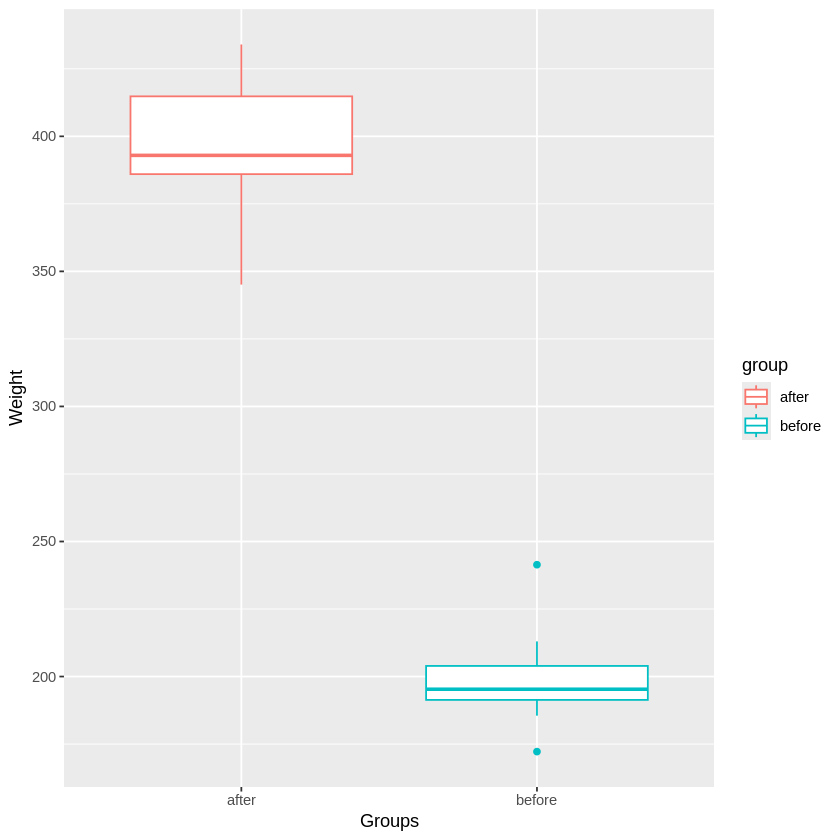

In [ ]:
ggplot(my_data, aes(x = group, y = weight, color=group))+
    geom_boxplot()+
    ylab("Weight")+xlab("Groups")

**Exercise**

Lets say we have a tutoring program and we would like to test whether the program improves exam scores for the same students in the math class. We have the following data:

In [ ]:
score1 <- c(85, 79, 81, 89, 90, 94, 80, 98, 84, 87, 91, 82) # Exam scores before completing the tutoring program
score2 <- c(95, 84, 89, 97, 92, 95, 87, 100, 87, 98, 99, 88) # Exam scores after completing the tutoring program

Use the following space to use the t.test() function to answer the following questions:

1. What is the alternative and null hypothesis in the context of this problem?
2. What is the p-value?
3. What is the confidence interval?
4. Based on these results, can we reject the null hypothesis? Why or why not?
5. Visualize the t-test

In [ ]:
# Write your code here

### **`Independent sample t-test`**  


Independent sample t-tests are good for comparing the difference in mean between two independent or unrelated groups.

Here we use the General Social Survey data, and test if *People who voted for Clinton and those who voted for Trump in 2016 election has the same level of family income*.

Use the variable *PRES16*: 1 for Clinton, 2 for Trump, 3 for Other, 4 for Didn’t vote. and the variable *realinc* for family income.

We first find the two groups we are comparing:

In [ ]:
Clinton <- subset(GSS, GSS$pres16 == 1)
Trump <- subset(GSS, GSS$pres16 == 2)


One of the assumptions of a Student’s two-sample t-test is that the variances of both samples are homogenous (variances do not differ significantly with each other).

In [ ]:
var.test(Clinton$realinc, Trump$realinc)


	F test to compare two variances

data:  Clinton$realinc and Trump$realinc
F = 1.1191, num df = 1386, denom df = 925, p-value = 0.06251
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.9941228 1.2580894
sample estimates:
ratio of variances 
          1.119129 


p>0.05 means the ratio of variance is almost equal to 1 (homogenous).

In [ ]:
# Student t-test
twogroupt <- t.test(Clinton$realinc, Trump$realinc, var.equal = TRUE, alternative = "two.sided")
twogroupt


	Two Sample t-test

data:  Clinton$realinc and Trump$realinc
t = 1.064, df = 2311, p-value = 0.2875
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1567.039  5284.474
sample estimates:
mean of x mean of y 
 44676.54  42817.82 


In [ ]:
# Welch t-statistic (does not have the assumption of equal variance)
twogroupt2 <- t.test(Clinton$realinc, Trump$realinc, var.equal = FALSE, alternative = "two.sided")
twogroupt2


	Welch Two Sample t-test

data:  Clinton$realinc and Trump$realinc
t = 1.076, df = 2057.2, p-value = 0.2821
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1529.071  5246.506
sample estimates:
mean of x mean of y 
 44676.54  42817.82 


What’s the null hypothesis in this test? Is this one-tailed or two-tailed? What’s the test statistics? What’s the p value? Can we reject the null hypothesis?

How we change the R script if we want to test whether *People who voted for Clinton has higher family income than those who voted for Trump in 2016 election*

Despite Boxplot, we can also visualize two-group t-test using histogram:

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 233 rows containing non-finite outside the scale range (`stat_bin()`).”


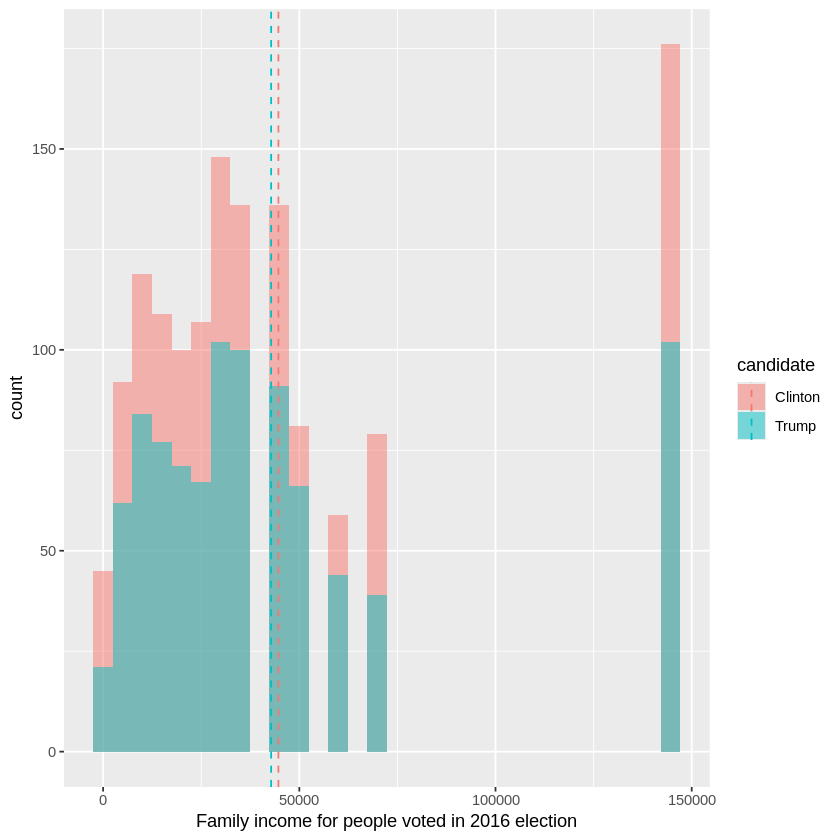

In [ ]:
GSS$candidate <- factor(GSS$pres16,
                      levels <- c(1,2),
                      labels <- c("Clinton","Trump"))

GSS_complete <- GSS[complete.cases(GSS[,"candidate"]),]

mu <- ddply(GSS_complete, "candidate", summarise, mean=mean(realinc, na.rm = TRUE))

ggplot(GSS_complete, aes(x=realinc, fill=candidate)) +
     geom_histogram(alpha=0.5, position="identity")+
     geom_vline(data=mu, aes(xintercept=mean, color=candidate), linetype="dashed")+
       xlab("Family income for people voted in 2016 election")


**Exercise**

Still use GSS data. Test the following hypothesis in R: (1) Whether male and female (variable sex, 1 for Male, 2 Female) has the equal level of family income (variable realinc). Answer the following questions:

1. What is the alternative and null hypothesis in the context of this problem?
2. What is the p-value?
3. What is the confidence interval?
4. Based on these results, can we reject the null hypothesis? Why or why not?
5. Visuazlize the test (using boxplot or histogram)


In [ ]:
# Write your code here

Male <- subset(GSS, sex=="1")

Female <- subset(GSS, sex=="2")

var.test(Male$realinc, Female$realinc)

t.test(Male$realinc, Female$realinc, var.equal = F, alternative = "two.sided" )


	F test to compare two variances

data:  Male$realinc and Female$realinc
F = 1.2521, num df = 1571, denom df = 1917, p-value = 2.794e-06
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 1.139645 1.376358
sample estimates:
ratio of variances 
          1.252141 



	Welch Two Sample t-test

data:  Male$realinc and Female$realinc
t = 7.0513, df = 3183.1, p-value = 2.165e-12
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  6990.538 12375.543
sample estimates:
mean of x mean of y 
 45474.07  35791.03 


## **ANOVA** ##

ANOVA tests are similar to independent sample t-tests except they can be used to compare the means of 2 or more independent groups. Please refer to the lecture slides for more detailed information regarding ANOVA tests. Here, we will demonstrate using them in R.

When dealing with ANOVA tests, we usually set up the Null Hypothesis and the Alternative Hypothesis as follows:
- Null Hypothesis: All population means are roughly equal.
- Alternate Hypothesis: At least one population mean is different from others.

There are two types of ANOVA tests:
- One-way ANOVA
- Two-way ANOVA
We are concerned with One-way ANOVA tests which deals with one categorical group

Using the GSS data, we test whether people with different party identifications have the same level of family income.

Use the variable `PARTYID`: 0 for strong democrat. 1 for not very strong democrat. 2 for independent, close to democrat. 3 for independent. 4 for independent, close to republican. 5 for not very strong republican. 6 for strong republican. 7 for don’t know.


In [ ]:
class(GSS$partyid) # check the data type of the group variable


[1] "numeric"

In [ ]:
GSS$partyid2 <- as.character(GSS$partyid) # make sure the group variable is character

list(unique(GSS$partyid2))

[[1]]
[1] "3" "2" "0" "1" "5" "7" "4" "6" NA

In [ ]:
GSS2 <- subset(GSS, GSS$partyid2 != "7") # delete don't know

ANOVA <- aov(realinc ~ partyid2, data=GSS2)

summary(ANOVA)

              Df    Sum Sq   Mean Sq F value   Pr(>F)    
partyid2       6 9.404e+10 1.567e+10   9.843 8.72e-11 ***
Residuals   3399 5.412e+12 1.592e+09                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
480 observations deleted due to missingness

The F-value column is the test statistic from the F test. The larger the F value, the more likely that the groups we are interested in are different.

The Pr(>F) column is the p-value of the F-statistic.

We can visualize the test using boxplot:

Warning message:
“Removed 480 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


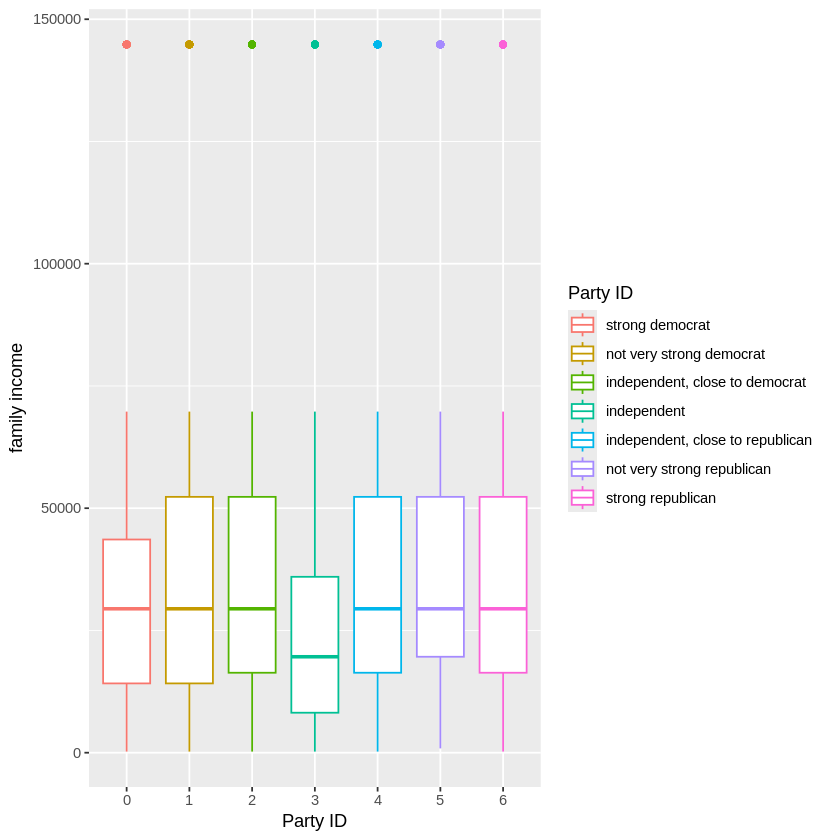

In [ ]:
ggplot(GSS2, aes(x = partyid2, y = realinc, color=partyid2))+
    geom_boxplot()+
    ylab("family income")+xlab("Party ID")+
    scale_colour_discrete(name = "Party ID",labels = c('strong democrat','not very strong democrat', 'independent, close to democrat', 'independent', 'independent, close to republican', 'not very strong republican', 'strong republican')) #change labels for legend

** Exercise **

Use the `ANES` data. Test if people living in different areas rate Bernie Sanders equally.

You will be using: `liveurban`. Do you currently live in a rural area, small town, suburb, or a city? 1 for rural area. 2 for small town. 3 for suburb. 4 for city; and

`ftsanders`: From 1 to 100, how would you rate Bernie Sanders? (-7 means no answer, 997 means don’t know). Be sure you delete no answer and don’t know before running statistical tests.

Answer the following questions:

1. What is the alternative and null hypothesis in the context of this problem?
2. What is the p-value?
3. What is the confidence interval?
4. Based on these results, can we reject the null hypothesis? Why or why not?
5. Visualize the test

In [ ]:
# Write your code here

ANES2 <- ANES[!(ANES$ftsanders==-7|ANES$ftsanders==997),]

class(ANES2$liveurban)
ANES2$liveurban2 <- as.character(ANES2$liveurban)
summary(ANES2$ftsanders)

class(ANES2$liveurban2)

ANOVA <- aov(ftsanders~liveurban2, data=ANES2)

ANOVA

summary(ANOVA)


[1] "numeric"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    5.00   42.00   42.15   73.00  100.00 

[1] "character"

Call:
   aov(formula = ftsanders ~ liveurban2, data = ANES2)

Terms:
                liveurban2 Residuals
Sum of Squares       77206   3717847
Deg. of Freedom          3      3116

Residual standard error: 34.54197
Estimated effects may be unbalanced

              Df  Sum Sq Mean Sq F value   Pr(>F)    
liveurban2     3   77206   25735   21.57 7.99e-14 ***
Residuals   3116 3717847    1193                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## **Chi-square test** ##

Chi-square tests are used to determine whether there is an association between two categorical variables (which may or may not be independent).

When dealing with Chi-square tests, we usually set up the Null Hypothesis and the Alternative Hypothesis as follows:
- Null hypothesis: Variable 1 is independent of variable 2
- Alternative hypothesis: Variable 1 is not independent of variable 2

Use GSS data, test if voting for Clinton or Trump is related to one’s party identification. Use the variables `pres16` and `partyid`

In [ ]:
GSS <- GSS[which(GSS$pres16 == 1 | GSS$pres16 == 2), ]

class(GSS$pres16) # make sure both variable is categorical

[1] "numeric"

In [ ]:
GSS$pres <- as.character(GSS$pres16)

GSS$partyid2 <- as.character(GSS$partyid) # make sure both variable is categorical

GSS2 <- subset(GSS, GSS$partyid2 != "7") # delete don't know

table(GSS2$pres, GSS2$partyid2)

   
      0   1   2   3   4   5   6
  1 681 340 286 108  28  28   9
  2   8  21  10 113 178 238 427

In [ ]:
chisq.test(GSS2$pres, GSS2$partyid2, correct = FALSE)


	Pearson's Chi-squared test

data:  GSS2$pres and GSS2$partyid2
X-squared = 1848.4, df = 6, p-value < 2.2e-16


We can use a bar plot to visualize chi-square test:


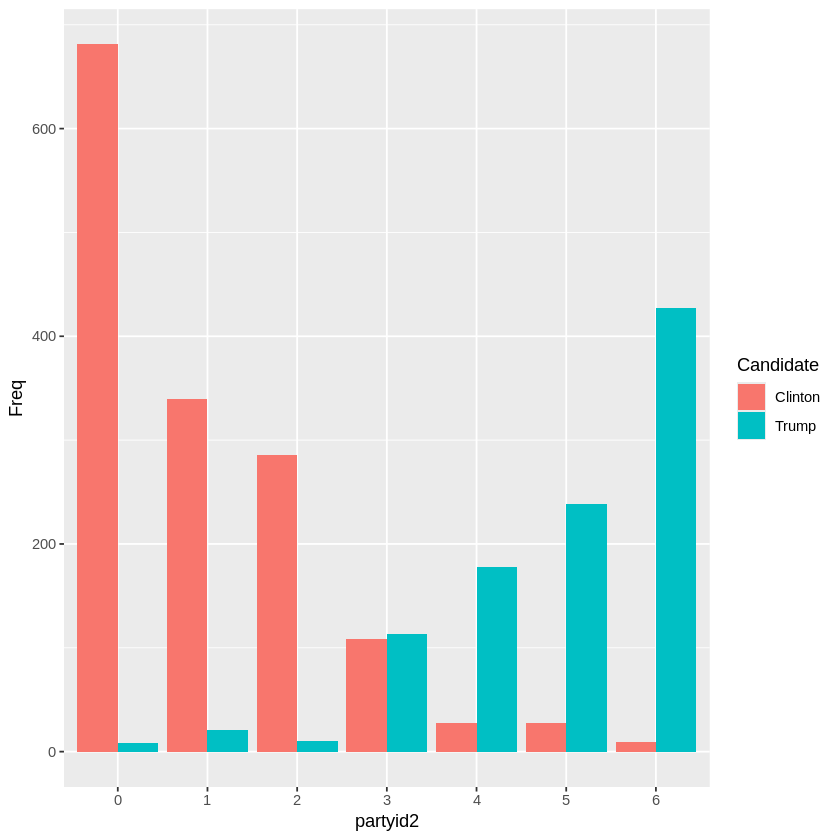

In [ ]:
table <- data.frame(with(GSS2, table(partyid2,pres)))

ggplot(table, aes(x=partyid2,y=Freq, fill=pres))+
  geom_bar(stat="identity",position="dodge")+
  scale_fill_discrete(name = "Candidate",labels = c('Clinton','Trump')) #change labels for legend


** Exercise **

Use the `ANES` data. Test if registered to vote is related to where the respondent is currently living in.

You will be using: `liveurban`. Do you currently live in a rural area, small town, suburb, or a city? 1 for rural area. 2 for small town. 3 for suburb. 4 for city; and

`reg1a`: Are you registered to vote, or not? -1 for inapplicable. 1 for Yes, registered to vote at my current address. 2 for Yes, registered to vote at a different address. 3 for No, not registered. (Make sure you delete inapplicable. You can also create a new variable for people registered at either current address or different address).

Answer the following questions:

1. What is the alternative and null hypothesis in the context of this problem?
2. What is the p-value?
3. What is the confidence interval?
4. Based on these results, can we reject the null hypothesis? Why or why not?
5. Visuazlize the test

In [ ]:
# Write your code here

ANES <- ANES[!(ANES$reg1a==-1),]

ANES$register <- ifelse(ANES$reg1a == 3, 0, 1) # Recode 1 and 2 to 1, 3 to 0

table(ANES$register, ANES$liveurban)

chisq.test(ANES$register, ANES$liveurban, correct = FALSE)


   
      1   2   3   4
  0  28  26  44  56
  1 264 287 507 374


	Pearson's Chi-squared test

data:  ANES$register and ANES$liveurban
X-squared = 7.9612, df = 3, p-value = 0.04682


## **Conclusion** ##

In this tutorial, we learned how to use R code to take a two sample t-test, an independent sample t-test, ANOVA test, and a chi-square test. We also learned how to evaluate them to make a conclusion regarding the validity of the null hypothesis. Finally, we learned about the differences between each test and when they should be used. Remember to consider the variances, the relationship between the groups, the number of groups, the type of data, etc. For more information on these concepts, please refer to the lecture slides and supplemental readings.